In [1]:
import sys
sys.path.append('../')

In [2]:
from importlib import reload
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Winkler/Warder titration
- titration of mixed NaOH + Na2CO3 solution by HCl
- w/ or w/o BaCl2 addition
- considers activity coefficient (Davies model)

# Load Data

In [3]:
import eq_solver
import summarize

# Settings

In [4]:
temp_deg = 25.0
s = eq_solver.EqSystem.from_yaml('Na-Ba-CO3.yaml', display_info=True, temperature=273.15+temp_deg)
# ----------------------------------------------------------------------------------------
# 100 mL of 0.08 mol/L NaOH + 0.01 mol/L Na2CO3 + some BaCl2, titrated by 1 mol/L HCl
# ----------------------------------------------------------------------------------------

v = 0.1
n_naoh = 0.08 * v
n_na2co3 = 0.01 * v
c_bacl2_list = [0.0, 0.005, 0.01, 0.1, 0.5, 1.0]
v_hcl_list = np.linspace(0.0, (n_naoh + n_na2co3) * 1.2, 100)
cond_list = []
for c_bacl2 in c_bacl2_list:
    n_bacl2 = c_bacl2 * v
    for v_hcl in v_hcl_list:
        v_total = v + v_hcl
        d = {
            'carbonate': n_na2co3 / v_total, 
            'barium': n_bacl2 / v_total, 
            'sodium': (n_naoh + 2*n_na2co3) / v_total, 
            'chloride': (v_hcl * 1.0 + 2 * n_bacl2) / v_total
        }
        cond_list.append(eq_solver.Conditions.from_dict(s, d))
print('------ args ------')
print(s.get_arg_names())
print('------ returns ------')
print(s.get_return_names())

'activity model: davies'

'---------- components ----------'

,name,base,constraint,charge
0,proton,H+,charge,1
1,carbonate,CO3^2-,total,-2
2,barium,Ba2+,total,2
3,sodium,Na+,direct,1
4,chloride,Cl-,direct,-1


'---------- species ----------'

,name,phase
0,H+,liquid
1,OH-,liquid
2,Na+,liquid
3,CO2aq,liquid
4,HCO3-,liquid
5,CO3^2-,liquid
6,Ba2+,liquid
7,[BaCO3]aq,liquid
8,[BaHCO3]aq,liquid
9,BaCO3(s),solid


'---------- equilibria ----------'

,name,logK,DH,composition,H+,OH-,CO2aq,HCO3-,CO3^2-,[BaCO3]aq,Ba2+,[BaHCO3]aq,BaCO3(s)
0,water autoionization,-14.00,57.0,"{'H+': 1, 'OH-': 1}",1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,CO2 deprotonation 1,-6.30,9.2,"{'CO2aq': -1, 'H+': 1, 'HCO3-': 1}",1.0,0.0,-1.0,1.0,0.0,0.0,0.0,0.0,0.0
2,CO2 deprotonation 2,-10.33,14.6,"{'H+': 1, 'CO3^2-': 1, 'HCO3-': -1}",1.0,0.0,0.0,-1.0,1.0,0.0,0.0,0.0,0.0
3,barium complex 1,2.71,16.7,"{'[BaCO3]aq': 1, 'Ba2+': -1, 'CO3^2-': -1}",0.0,0.0,0.0,0.0,-1.0,1.0,-1.0,0.0,0.0
4,barium complex 2,0.98,25.4,"{'[BaHCO3]aq': 1, 'Ba2+': -1, 'HCO3-': -1}",0.0,0.0,0.0,-1.0,0.0,0.0,-1.0,1.0,0.0
5,BaCO3(s) precipitation,-8.57,4.2,"{'Ba2+': 1, 'CO3^2-': 1, 'BaCO3(s)': -1}",0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,-1.0


'---------- species from base components ----------'

,H+,CO3^2-,Ba2+,Na+,Cl-,logK
H+,1.0,-0.0,-0.0,-0.0,0.0,-0.00
OH-,-1.0,0.0,0.0,-0.0,0.0,-14.00
Na+,-0.0,0.0,0.0,1.0,0.0,-0.00
CO2aq,2.0,1.0,-0.0,-0.0,0.0,16.63
HCO3-,1.0,1.0,-0.0,-0.0,0.0,10.33
CO3^2-,0.0,1.0,0.0,0.0,0.0,0.00
Ba2+,0.0,0.0,1.0,-0.0,0.0,0.00
[BaCO3]aq,0.0,1.0,1.0,-0.0,0.0,2.71
[BaHCO3]aq,1.0,1.0,1.0,-0.0,0.0,11.31
BaCO3(s),0.0,1.0,1.0,-0.0,0.0,8.57


------ args ------
['Log a(H+)', 'Log a(CO3^2-)', 'Log a(Ba2+)', 'mole(BaCO3(s))', 'I']
------ returns ------
['carbonate mole conservation', 'barium mole conservation', 'solid-liquid eq. of BaCO3(s)', 'charge conservation', 'self-consistency of I']


# Calculation

In [5]:
results = eq_solver.solve_for_conditions(s, cond_list)

In [6]:
df = summarize.get_summary(results)
df_C = summarize.get_distribution(results, 'carbonate', relative=True)

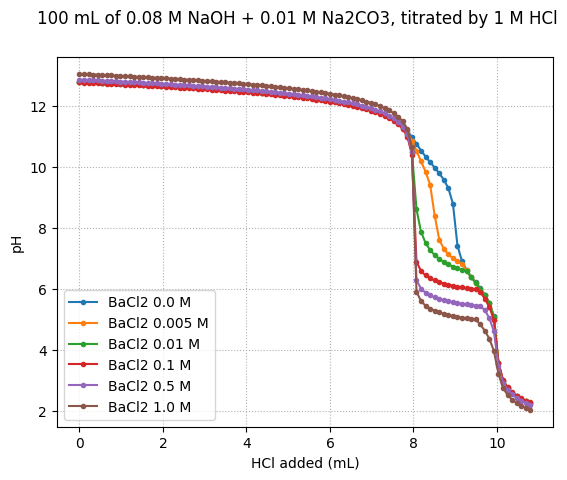

In [7]:
plt.figure()
plt.suptitle('100 mL of 0.08 M NaOH + 0.01 M Na2CO3, titrated by 1 M HCl')
for i, c_bacl2 in enumerate(c_bacl2_list):
    n = len(v_hcl_list)
    sub_df = df.iloc[i*n:(i+1)*n, :]
    plt.plot(v_hcl_list*1000, sub_df['pH'], '.-', label=f'BaCl2 {c_bacl2} M')
plt.ylabel('pH')
plt.xlabel('HCl added (mL)')
plt.legend()
plt.grid(True, ls=':')
plt.show()

Text(0, 0.5, 'Distribution (%)')

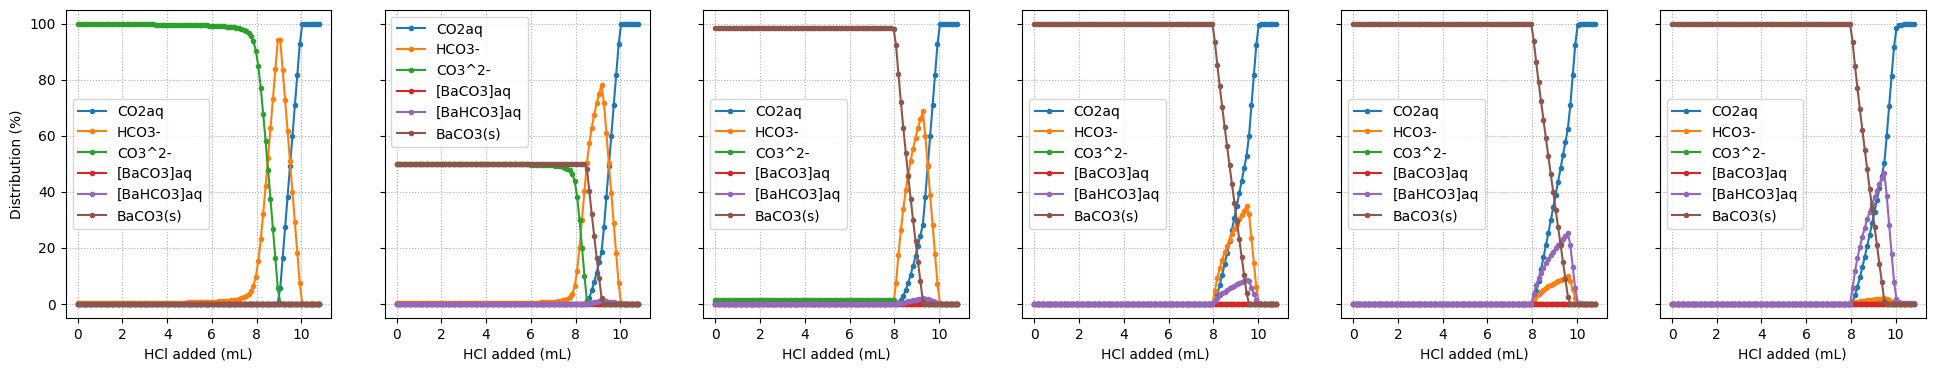

In [8]:
ncols = len(c_bacl2_list)

fig, axes = plt.subplots(ncols=ncols, sharex=True, sharey=True)
fig.set_size_inches(ncols*4, 4)

for i in range(ncols):
    cols = [c for c in df_C.columns if 'C' in c and 'cond.' not in c]
    n = len(v_hcl_list)
    sub_df = df_C.iloc[i*n:(i+1)*n,:]
    axes[i].plot(v_hcl_list*1000, sub_df[cols], '.-', label=sub_df[cols].columns)
for ax in axes:
    ax.legend()
    ax.set_xlabel('HCl added (mL)')
    ax.grid(True, ls=':')
axes[0].set_ylabel('Distribution (%)')


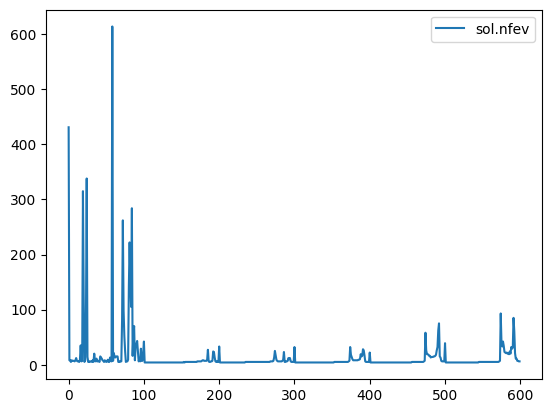

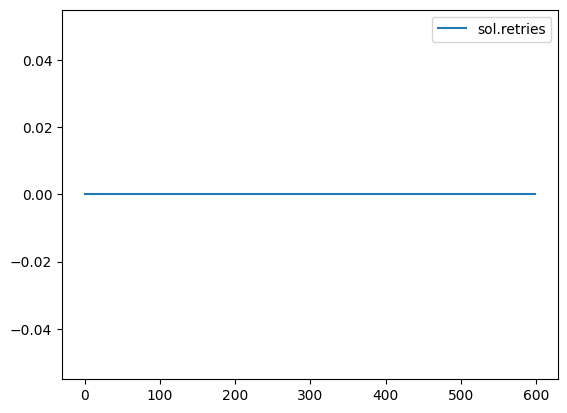

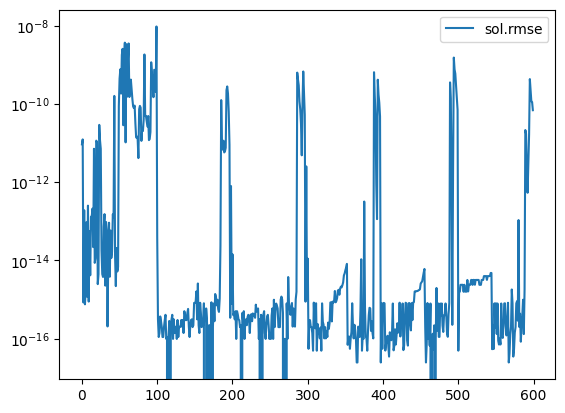

In [9]:
# convergence w/o Ba is unstable, but rmse is small enough.
df.plot(y='sol.nfev')
df.plot(y='sol.retries')
df.plot(y='sol.rmse')
plt.yscale('log')